# LLM JUDGE TEST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns

#enable pandas tdqm
from tqdm import tqdm
tqdm.pandas()

In [3]:
%cd f:/robusto/vqa_analysis

f:\robusto\vqa_analysis


In [2]:
#load answers text cache
answers_text_cache_path = "../../data/r2_cleaned.csv"
df_answers = pd.read_csv(answers_text_cache_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers = df_answers[df_answers["REPETITION"] == 1].reset_index(drop=True)
# drop block 2
df_answers = df_answers[df_answers["BLOCK"] != 2].reset_index(drop=True)
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
print(f"Loaded answers text cache with {len(df_answers)} entries")
df_answers.head()

Loaded answers text cache with 7500 entries


,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC


In [3]:
KEYS = ["VIDEO", "QUESTION_NUM","VIDEO_SECTOR", "BLOCK", "AGENT","ANSWER"]
df_comp = pd.merge(df_answers[KEYS], df_answers[KEYS], on=["VIDEO", "QUESTION_NUM","VIDEO_SECTOR","BLOCK"], suffixes=('_I', '_J')) 
df_comp

,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...
...,...,...,...,...,...,...,...,...
187495,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,MiniCPM-o-2_6,"I'm sorry, but I cannot provide an analysis of..."
187496,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Perception-LM-8B,"No, there is no vehicle or pedestrian in the s..."
187497,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Phi-4-multimodal-instruct,"No, there are no visible signs of any vehicles..."
187498,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Qwen3-VL-8B-Instruct,No vehicle or pedestrian is visibly violating ...


## JUDGER

In [4]:
JUDGE_TEMPLATE = """
You are a strict and impartial evaluator.

Task:
Assess semantic agreement between Response A and Response B with respect to the same question about an urban driving scene.

Rules:
- Compare only explicit factual claims.
- Ignore style, tone, verbosity, and grammar.
- Do not reward verbosity.
- Do not infer or assume unstated facts.
- If one response is vague/empty and the other is specific, score 0 unless there is explicit contradiction.
- Use the full scale only when justified by explicit claim overlap/conflict.

Scoring:
+2 = Strong agreement: same core claims, no meaningful differences.
+1 = Partial agreement: mostly aligned, minor differences or omissions.
0 = No clear relation: little/no overlapping claims, or insufficient comparable content.
-1 = Partial contradiction: at least one important claim conflicts.
-2 = Direct contradiction: opposing claims about the same fact.

Output:
Return ONLY valid JSON (no markdown, no extra text):
{{
  "Evaluation": "<1-4 concise sentences based only on explicit claims>",
  "Score": -2 | -1 | 0 | 1 | 2
}}

Input:
    Response A: {res_a}
    Response B: {res_b}
"""

import os
from openai import AsyncOpenAI

VLLM_BASE_URL = os.getenv("VLLM_BASE_URL", "http://localhost:8000/v1")
VLLM_API_KEY = os.getenv("VLLM_API_KEY", "EMPTY")
JUDGE_MODEL = os.getenv("VLLM_MODEL", "Qwen/Qwen3-4B")

aclient = AsyncOpenAI(
    base_url=VLLM_BASE_URL,
    api_key=VLLM_API_KEY,
 )

def _normalize_message_field(value):
    if value is None:
        return ""
    if isinstance(value, list):
        return "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in value
        ).strip()
    return str(value).strip()

# Get score using the model
async def judge_row_answers_async(row):
    prompt = JUDGE_TEMPLATE.format(
        res_a=row['ANSWER_I'],
        res_b=row['ANSWER_J']
    )
    
    completion = await aclient.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {"role": "system", "content": "You are an impartial judge."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.6,
        max_tokens=32768
    )

    msg = completion.choices[0].message
    content = _normalize_message_field(msg.content)
    reasoning_content = _normalize_message_field(
        getattr(msg, "reasoning_content", None) or getattr(msg, "reasoning", None)
    )

    return {
        "raw_output": content,
        "reasoning_content": reasoning_content,
    }
 
def judge_row_answers(row):
    raise RuntimeError("Use `await judge_row_answers_async(row)` in this notebook.")

In [5]:
import json
import re

def _extract_json_dict(text):
    text = text.strip()

    # Remove fenced code block wrappers if present
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
        text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parse
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fallback: parse first JSON object found in the text
    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("No JSON object found in model output")
    return json.loads(match.group(0))

# test on a single row
row = df_comp.iloc[0]
result_payload = await judge_row_answers_async(row)
print(f"Raw output:\n{result_payload['raw_output']}\n")
print(f"Reasoning content:\n{result_payload['reasoning_content']}\n")
print("JSON:")
print(json.dumps(_extract_json_dict(result_payload["raw_output"]), indent=2))

Raw output:
{
  "Evaluation": "Both responses state the same explicit cause-effect relationship: the ego vehicle's slow acceleration is due to a yellow van changing lanes.",
  "Score": 2
}

Reasoning content:
Okay, let's tackle this evaluation. So, the task is to compare Response A and Response B for semantic agreement regarding an urban driving scene. The rules say to focus only on explicit factual claims and ignore style, tone, etc. 

First, I need to look at both responses. Both A and B state that the ego vehicle is accelerating slowly because a yellow van is changing lanes in front of it. The key here is to check if they have the same core claims. 

Response A says the reason for the slow acceleration is the yellow van changing lanes. Response B says the same thing. There's no difference in the explicit claims here. Both mention the same cause and effect. 

Since there's no contradiction and both are specific, they should have strong agreement. The scoring rules say +2 for strong a

In [6]:
import asyncio
import json
import re

def _extract_json_dict(text):
    text = text.strip()

    # Remove fenced code block wrappers if present
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
        text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parse
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fallback: parse first JSON object found in the text
    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("No JSON object found in model output")
    return json.loads(match.group(0))

async def comparation_func_async(row, sem):
    async with sem:
        try:
            result_payload = await judge_row_answers_async(row)
            result = _extract_json_dict(result_payload["raw_output"] or "")
            agreement_score = result.get("Score", np.nan)
            evaluation = result.get("Evaluation", "")
            reasoning_content = result_payload.get("reasoning_content", "")
        except Exception:
            agreement_score = np.nan
            evaluation = ""
            reasoning_content = ""
    return agreement_score, evaluation, reasoning_content

async def score_dataframe_async(
    df,
    checkpoint_path,
    concurrency=32,
    batch_size=256,
    checkpoint_every_batches=10,
 ):
    sem = asyncio.Semaphore(concurrency)
    
    for batch_i, start in enumerate(tqdm(range(0, len(df), batch_size), desc="Scoring batches"), start=1):
        end = min(start + batch_size, len(df))
        idxs = list(range(start, end))
        rows = [df.iloc[i] for i in idxs]
        
        tasks = [comparation_func_async(row, sem) for row in rows]
        results = await asyncio.gather(*tasks)
        
        for i, (score, evaluation, reasoning_content) in zip(idxs, results):
            df.at[i, "SCORE"] = score
            df.at[i, "EVALUATION"] = evaluation
            df.at[i, "REASONING_CONTENT"] = reasoning_content
        
        if batch_i % checkpoint_every_batches == 0:
            df.to_parquet(checkpoint_path)

    df.to_parquet(checkpoint_path)
    return df

# parallel scoring + checkpointing
checkpoint_path = "./llm_agreement_scores_qwen3_vllm.parquet"
df_comp = await score_dataframe_async(
    df_comp,
    checkpoint_path=checkpoint_path,
    concurrency=32,
    batch_size=256,
    checkpoint_every_batches=2,
 )

df_comp

Scoring batches:  34%|███▎      | 247/733 [3:54:39<7:41:43, 57.00s/it] 


CancelledError: 

In [7]:
#Now plot the df_comp
agg_df = (
    df_comp
    .groupby(
        ["VIDEO", "QUESTION_NUM","BLOCK","VIDEO_SECTOR", "AGENT_I", "AGENT_J"],
        as_index=False
    )["SCORE"]
    .mean()
)

agg_df2 = (
    agg_df
    .groupby(
        ["AGENT_I", "AGENT_J", "BLOCK","VIDEO_SECTOR"],
        as_index=False
    )["SCORE"]
    .mean()
)   
agg_df2

,AGENT_I,AGENT_J,BLOCK,VIDEO_SECTOR,SCORE
0,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,LIMA,NaN
1,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,NYC,NaN
2,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,LIMA,NaN
3,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,NYC,NaN
4,Cosmos-Reason2-8B,Cosmos-Reason2-8B,4,LIMA,NaN
...,...,...,...,...,...
3745,human_nyc_15,human_nyc_15,1,NYC,2.000000
3746,human_nyc_15,human_nyc_15,3,LIMA,2.000000
3747,human_nyc_15,human_nyc_15,3,NYC,2.000000
3748,human_nyc_15,human_nyc_15,4,LIMA,1.866667


In [8]:
def plot_judge(rsa_df, agents, title):
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),sharex=True,sharey=True)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            
            #select the data for the region and block
            df_block = rsa_df[(rsa_df["VIDEO_SECTOR"] == region) & (rsa_df["BLOCK"] == block)]
            rsa_matrix = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="SCORE")
            
            #order columns and rows by agents order
            rsa_matrix = rsa_matrix.reindex(index=agents, columns=agents)
            sns.heatmap(rsa_matrix.to_numpy(), annot=False, xticklabels=rsa_matrix.columns, yticklabels=rsa_matrix.columns, cmap=c, ax=c_ax,square=True, vmin=-2, vmax=2,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
            
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    fig.tight_layout()
    fig.savefig(f"./judge_output_{out_name}.png", dpi=300)

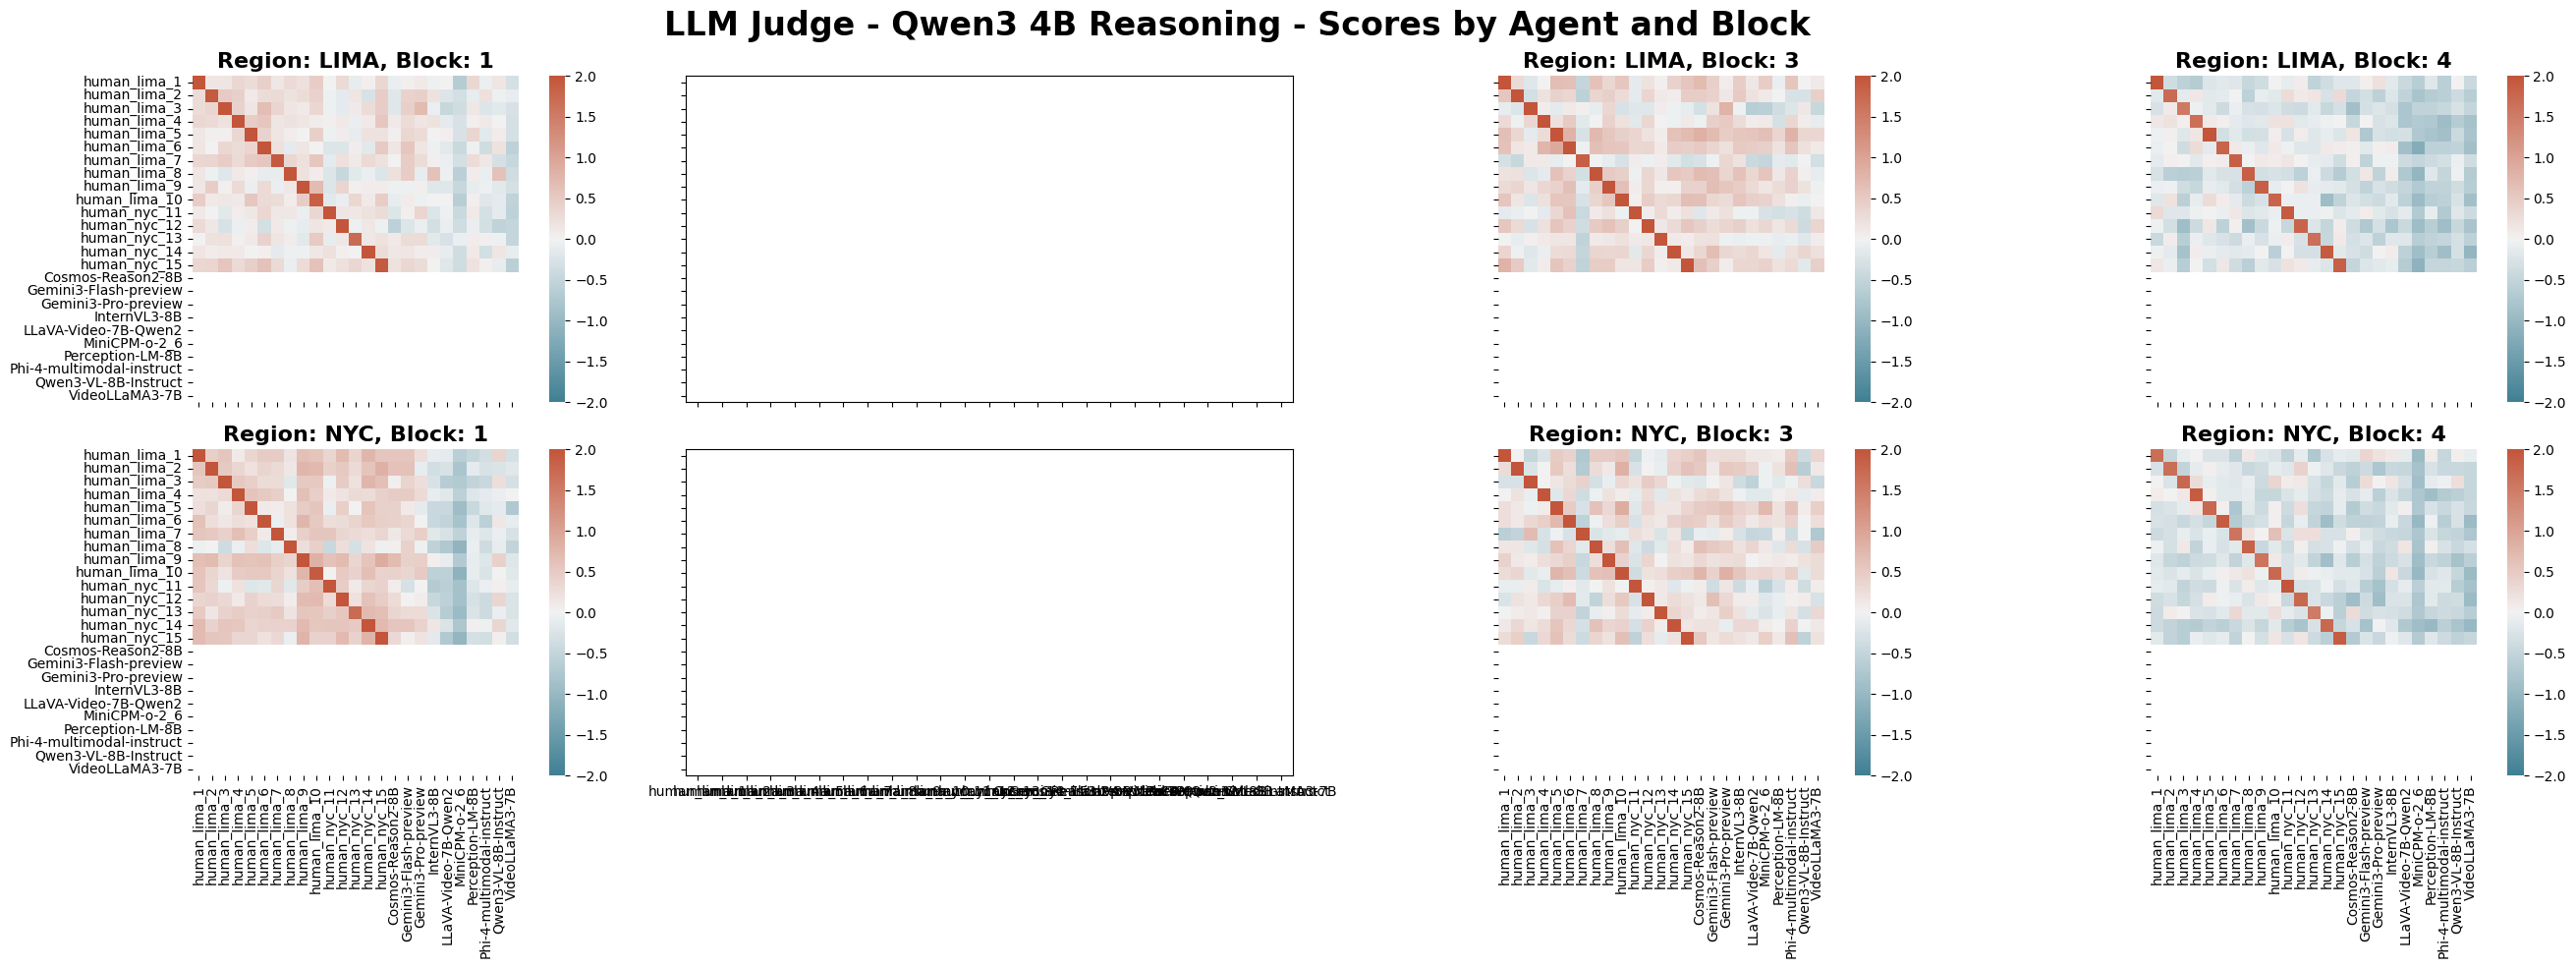

In [10]:
plot_judge(agg_df2, agents=df_answers["AGENT"].unique(), title="LLM Judge - Qwen3 4B Reasoning - Scores by Agent and Block")